In [170]:
# Generic packages
import numpy as np 
import matplotlib.pyplot as plt
from os import listdir

# Style 
plt.style.use('seaborn-pastel')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.model_selection import train_test_split
from sklearn.manifold import Isomap, TSNE, SpectralEmbedding, LocallyLinearEmbedding, MDS
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering

### Functions

In [173]:
def build_dataset(path):
    """
    build_dataset(path)

        Import dataset from path, normalize data and separate in train and test datasets.

        -path (str) : Path to the dataset files. 
    """
    TES = np.concatenate([np.fromfile(f"{path}{fileName}",dtype=np.uint16).reshape(-1,496) for fileName in listdir(path)])
    shape = np.shape(TES)

    #X = (X - np.mean(X)) / (np.std(X))
    X = (TES - np.min(TES)) / (np.max(TES) - np.min(TES))

    X_train, X_test = train_test_split(X, test_size=0.001, random_state=0)

    print(f"Dataset contains :",
        f"\nSamples : {shape[0]}",
        f"\nLenght of samples : {shape[1]}",
        f"\nNumber of train samples : {len(X_train)}",
        f"\nNumber of test samples {len(X_test)}")
    
    return X_train , X_test

In [171]:
def reduction(X,function,plot=False, **param):
    """
    # reduction(X,function,plot=False,**param)

    Verifies if a function has been saved in the `DR preprocess` folder to avoid unnecessary computation. 

    -X (array-like, sparse matrix) : Inputs of the function that needs to be computed.
    -function (function) : Function that is executed.
    -param (**kwargs) : Multiple keyword arguments to define the parameters of `function`.
    
    """
    # File name
    file_name = f"{str(function.__name__)}_{str(param.items())}"
    print("File name : ", file_name)

    # Check for existing file
    try:
        result = np.load(f"DR preprocess\{file_name}.npy",allow_pickle=True)

    # Compute operation if file does not exist
    except:
        method = function(**param)
        result = method.fit_transform(X)
        np.save(f"DR Log\{file_name}",arr=result)
    
    # Plot results
    if plot:
        plt.scatter(result[:, 0], result[:, 1],alpha=0.005)
        plt.xlabel('First principal component')
        plt.ylabel('Second principal component')

    #plt.hist2d(result[:, 0], result[:, 1],bins=300)

    return result

In [174]:
def clustering(X, function, label_return = False,**param):
    """
    # clustering(X,function,**param)

        Run and plot a clustering technique defined with the function parameter.
        The process is based on `sklearn` structure.

    -X (array-like, sparse matrix) : Inputs of the function that needs to be computed.
    -function (function) : Function that is executed.
    -param (**kwargs) : Multiple keyword arguments to define the parameters of `function`.
    """

    labels = function(**param).fit_predict(X)

    plt.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='Pastel2', alpha=0.05)
    plt.xlabel('First principal component')
    plt.ylabel('Second principal component')

    if label_return:
        return label_return


### Plot TES

Dataset contains : 
Samples : 52224 
Lenght of samples : 496 
Number of train samples : 52171 
Number of test samples 53


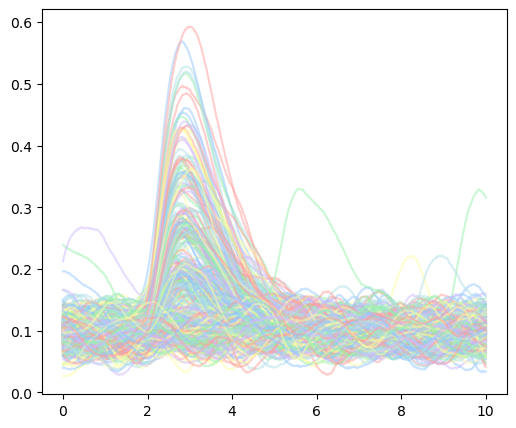

In [6]:
X, X_test = build_dataset("Datasets/Guillaume Thekkadath/")
signalSize = len(X_test[0])
time = np.linspace(0,10,signalSize)

plt.figure(figsize=(6,5))
plot = [plt.plot(time, X[i],alpha=0.5) for i in range(signalSize)]

### Principal Component Analysis (PCA)

File name :  PCA_dict_items([('n_components', 2)])


c:\Users\dalbe\anaconda3\lib\site-packages\sklearn\mixture\_base.py:277: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


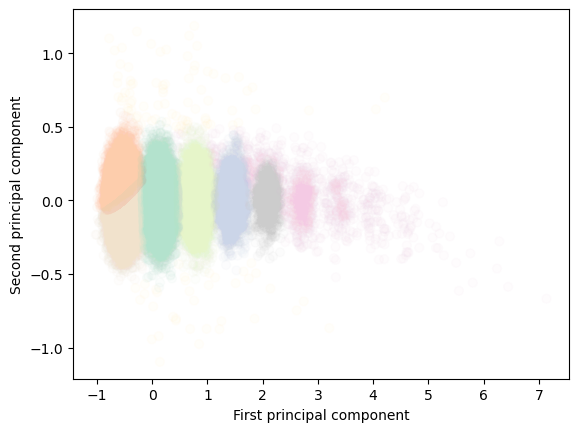

In [7]:
X_pca = reduction(X,PCA,n_components=2)
clustering(X_pca,BayesianGaussianMixture,reg_covar=1e-05,n_components=8, covariance_type='full', random_state=42)

### Kernel 

#### Polynomial

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'poly')])


c:\Users\dalbe\anaconda3\lib\site-packages\sklearn\mixture\_base.py:277: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


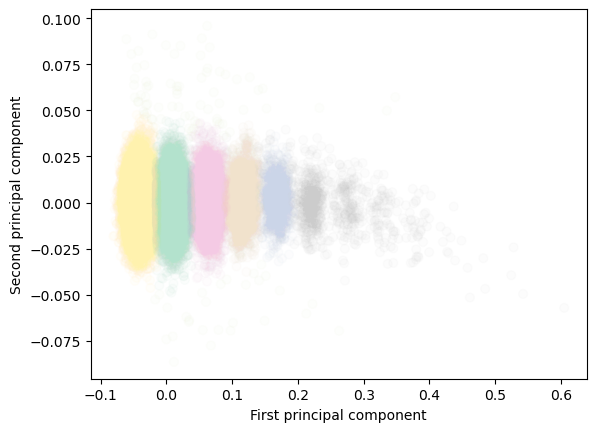

In [8]:
X_kernel_poly = reduction(X,KernelPCA,n_components=2,kernel="poly")
clustering(X_kernel_poly,BayesianGaussianMixture,reg_covar=1e-05,n_components=8, covariance_type='full', random_state=42)

#### Radial basis function (RBF)

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'rbf'), ('gamma', 0.02)])


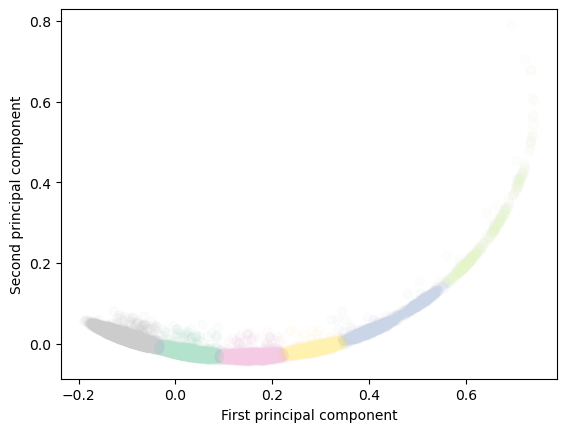

In [9]:
X_kernel_rbf = reduction(X,KernelPCA,n_components=2,kernel="rbf",gamma=0.02)
clustering(X_kernel_rbf,BayesianGaussianMixture,reg_covar=1e-04,n_components=8, covariance_type='full', random_state=42)

#### Sigmoid

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'sigmoid'), ('gamma', 0.02)])


c:\Users\dalbe\anaconda3\lib\site-packages\sklearn\mixture\_base.py:277: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


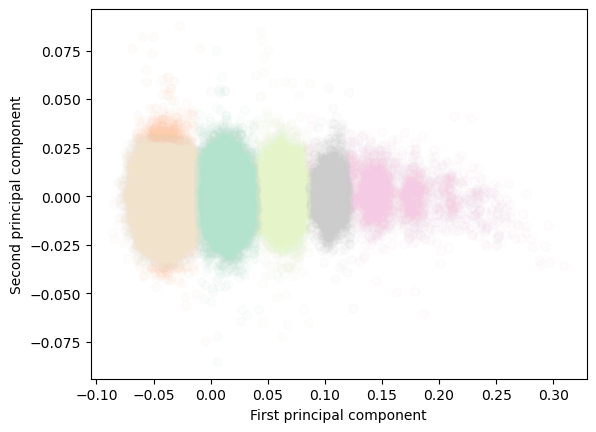

In [10]:
X_kernel_sigmoid = reduction(X,KernelPCA,n_components=2,kernel="sigmoid",gamma=0.02)
clustering(X_kernel_sigmoid,BayesianGaussianMixture,reg_covar=1e-05,n_components=6, covariance_type='full', random_state=42)

#### Cosine

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'cosine'), ('gamma', 0.02)])


c:\Users\dalbe\anaconda3\lib\site-packages\sklearn\mixture\_base.py:277: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


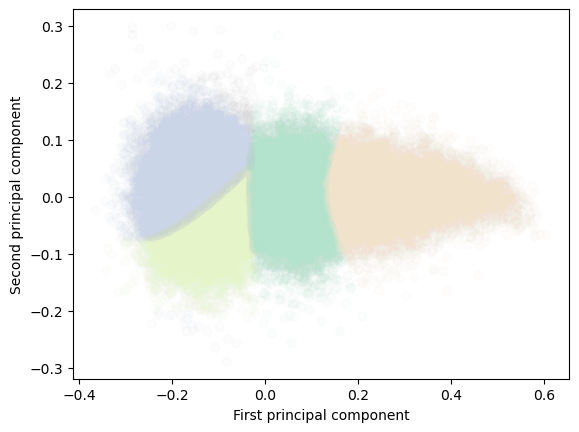

In [11]:
X_kernel_cosine = reduction(X,KernelPCA,n_components=2,kernel="cosine",gamma=0.02)
clustering(X_kernel_cosine,BayesianGaussianMixture,reg_covar=1e-04,n_components=5, covariance_type='full', random_state=42)

### t-distributed Stochastic Neighbor Embedding (t-SNE)



File name :  TSNE_dict_items([('random_state', 42), ('n_components', 2), ('init', 'random'), ('learning_rate', 200)])


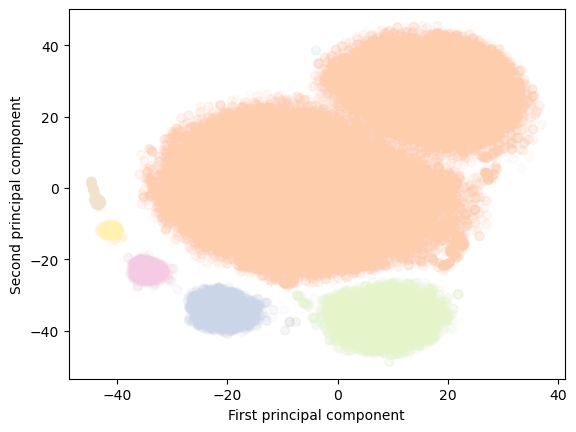

In [12]:
X_tsne = reduction(X,TSNE,random_state=42,n_components=2,init="random",learning_rate=200)
clustering(X_tsne,DBSCAN,eps=2.5)

### Non-Negative Matrix Factorization (NMF)

File name :  NMF_dict_items([('n_components', 4), ('alpha_W', 0.1), ('random_state', 42)])


c:\Users\dalbe\anaconda3\lib\site-packages\sklearn\mixture\_base.py:277: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


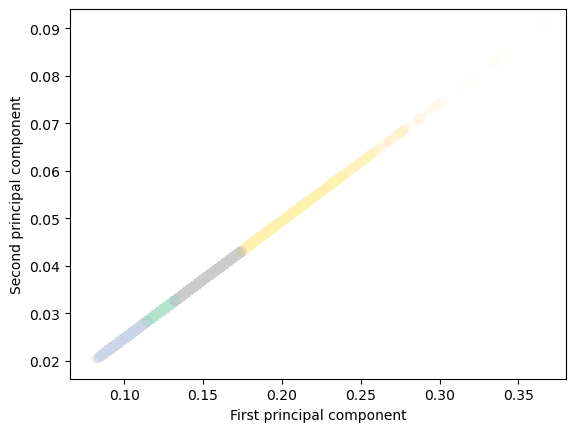

In [13]:
X_NMF = reduction(X,NMF,n_components=4,alpha_W=0.1,random_state=42)
clustering(X_NMF,BayesianGaussianMixture,reg_covar=1e-06,n_components=4, covariance_type='full', random_state=42)

### Isomap

File name :  Isomap_dict_items([('n_neighbors', 20), ('n_components', 2), ('eigen_solver', 'arpack')])


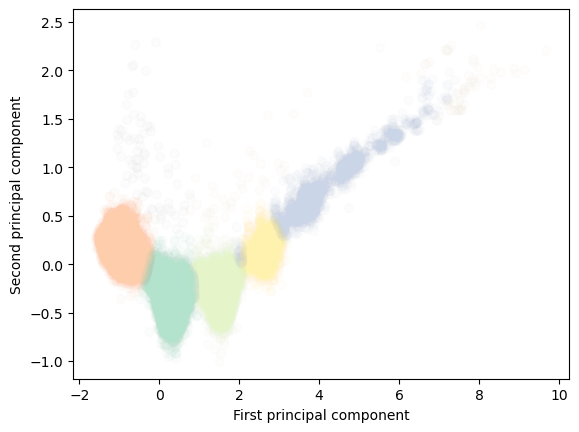

In [14]:
X_Isomap = reduction(X,Isomap,n_neighbors=20, n_components=2, eigen_solver="arpack")
clustering(X_Isomap,BayesianGaussianMixture,reg_covar=1e-02,n_components=7, covariance_type='full', random_state=42)

### Multidimensional scaling

File name :  MDS_dict_items([('n_components', 2), ('max_iter', 10)])


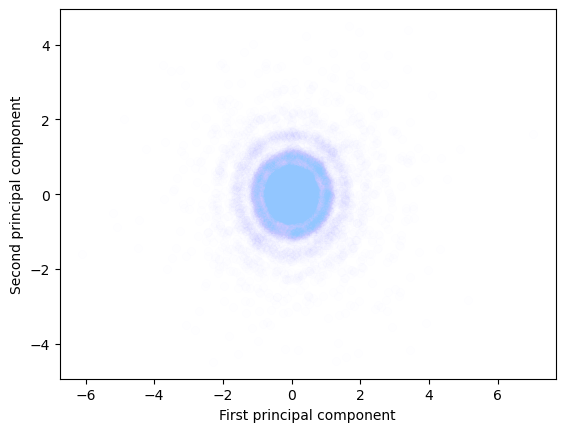

In [15]:
X_MDS = reduction(X,MDS,plot=True,n_components=2,max_iter=10)
#clustering(X_MDS,SpectralClustering,n_clusters=6)

### Locally Linear Embedding (LLE)

File name :  LocallyLinearEmbedding_dict_items([('n_components', 2)])


c:\Users\dalbe\anaconda3\lib\site-packages\sklearn\mixture\_base.py:277: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


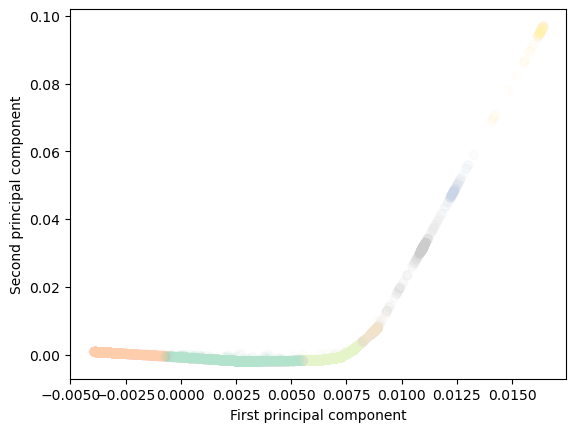

In [16]:
X_LLE = reduction(X,LocallyLinearEmbedding,n_components=2)
clustering(X_LLE,BayesianGaussianMixture,reg_covar=1e-06,n_components=7, covariance_type='full', random_state=42)

### Custom autoencoder

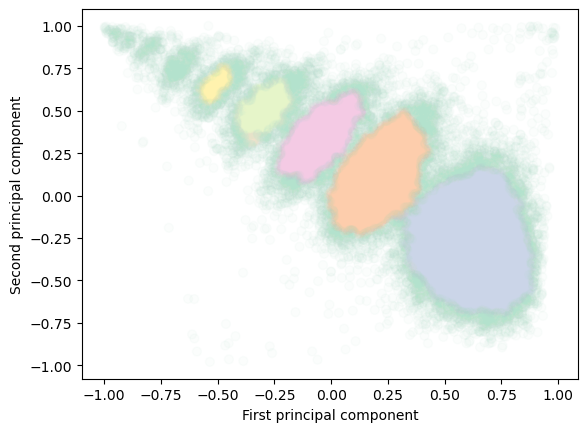

In [175]:
date_time = "sweep-conv-2d-3/sweep 3"
path_save = f"NN Log/{date_time}/"

X_autoencoder = np.load(f"{path_save}results.npy",allow_pickle=True).reshape(-1,2)
clustering(X_autoencoder,DBSCAN, eps=0.0201,min_samples = 30)

c:\Users\dalbe\anaconda3\lib\site-packages\sklearn\mixture\_base.py:277: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


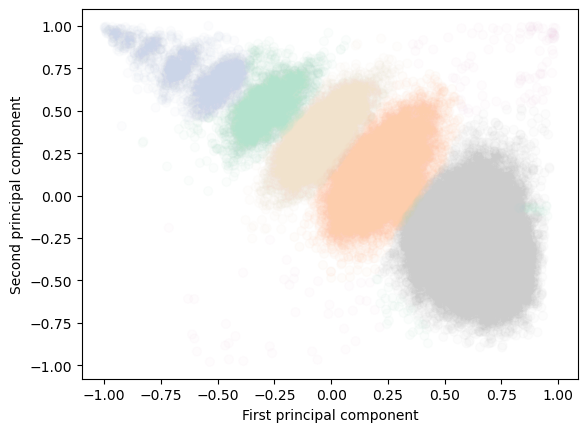

In [176]:
clustering(X_autoencoder,BayesianGaussianMixture,reg_covar=1.5e-03,n_components=10, covariance_type='full', random_state=42)